<a href="https://colab.research.google.com/github/Maryam-Skaik/bank-marketing-subscription-prediction/blob/main/bank_marketing_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing Classification

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
pd.set_option('display.max_columns', 50)

## Load Dataset

In [ ]:
X = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Practice/Data/df_X.csv')
y = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Practice/Data/df_y.csv')

# Combine the features and target into one DataFrame (optional, but useful)
df = pd.concat([X, y], axis=1)
df.head()

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,Unnamed: 0,y
0,0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,0,no
1,1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,1,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,2,no
3,3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,3,no
4,4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,4,no


- From first view, we can see 2 unrequired column `Unnamed: 0`.
- also we can see a lot of missing values in (`job`, `education`, `contact`, `poutcome`), need to handle by imputation before building model
- Dataset conatains numeric, categorical, and ordinal columns

In [ ]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


This dataset is from a bank's marketing campaign, aimed at predicting if a client will subscribe to a term deposit based on various factors.

### Columns Description

- **age**: The age of the individual (in years).
- **job**: The type of job the individual holds (e.g., management, technician, blue-collar, etc.).
- **marital**: The marital status of the individual (e.g., married, single).
- **education**: The education level of the individual (e.g., tertiary, secondary, or missing).
- **default**: Whether the individual has credit in default ("yes" or "no").
- **balance**: The individual's bank balance (in currency units).
- **housing**: Whether the individual has a housing loan ("yes" or "no").
- **loan**: Whether the individual has a personal loan ("yes" or "no").
- **contact**: The mode of communication used for the marketing campaign (e.g., "NaN" might indicate missing or unspecified).
- **day_of_week**: The day of the week when the last contact was made (e.g., 5 represents Friday).
- **month**: The month when the last contact was made (e.g., "may").
- **duration**: The duration of the last contact (in seconds).
- **campaign**: The number of contacts performed during this campaign for this individual.
- **pdays**: The number of days since the individual was last contacted in a previous campaign (-1 means no previous contact).
- **previous**: The number of contacts performed before this campaign.
- **poutcome**: The outcome of the previous marketing campaign (e.g., "NaN" for no previous contact, or a specific outcome like "success" or "failure").
- **y**: Whether the individual subscribed to a term deposit ("yes" or "no").

## Understanding the dataset


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


- Dataset contains 45211 rows and 17 columns
- All data types are consistent with features, so no need for converting data types

In [ ]:
df.describe().round(2)

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


- **Age**: The average age is 40.94 years, with most individuals falling between 33 and 48 years (25th to 75th percentile).
- **Balance**: The average balance is 1362.27, with a high spread (standard deviation of 3044.77). Some individuals have significantly lower or higher balances.
- **Day of Week**: The contact days range from 1 to 31, with a mean of 15.81, indicating marketing contacts were spread across the week, mainly mid-week.
- **Duration of Call**: The average call duration is 258.16 seconds (around 4-5 minutes), but with significant variation, some calls lasted up to 4918 seconds (82 minutes).
- **Campaign Contact Count**: Individuals were contacted an average of 2.76 times, with some contacted up to 63 times.
- **Days Since Last Contact (pdays)**: Most clients have a **pdays** value of -1, indicating no previous contact or missing data. The average is 40.20 days since previous contact.
- **Previous Contacts**: Most individuals have 0 previous contacts, indicating they are new to the campaign, while the maximum is 275, suggesting some clients were contacted frequently before.

## Handling duplicates, missing values, and inconsistencies

### Duplicates

In [ ]:
duplicated_rows = df.duplicated()
duplicated_rows.sum()

np.int64(0)

### Categorical inconsistencies

In [ ]:
df['marital'].value_counts()

,count
marital,
married,27214
single,12790
divorced,5207


In [ ]:
df['poutcome'].value_counts()

,count
poutcome,
failure,4901
other,1840
success,1511


In [ ]:
df['contact'].value_counts()

,count
contact,
cellular,29285
telephone,2906


### Handling Constant / Non-Informative Features

In [ ]:
df = df.drop(columns=['duration', 'poutcome'])
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,1,-1,0,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,1,-1,0,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,1,-1,0,no


### Missing Values

In [ ]:
df.isna().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


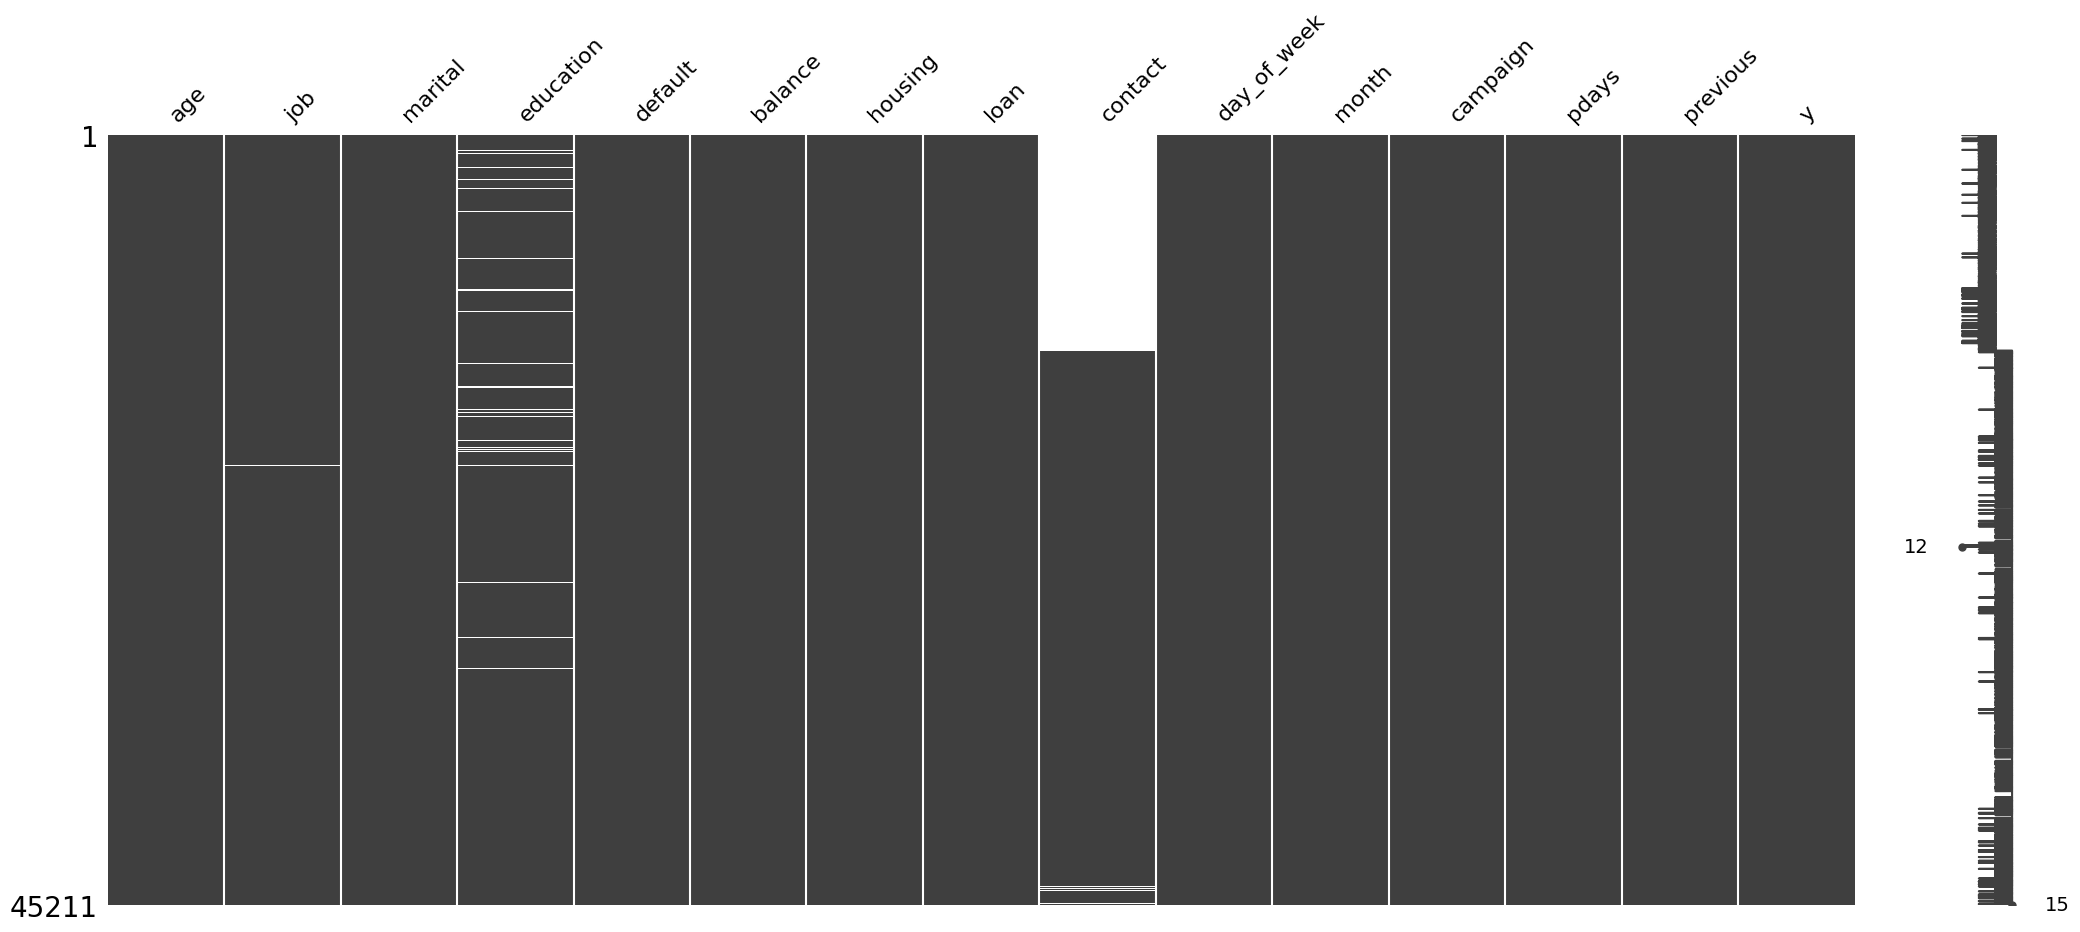

In [ ]:
import missingno as msno
msno.matrix(df);

In [ ]:
df['contact'] = df['contact'].fillna('MISSING')
df['education'] = df['education'].fillna('MISSING')
df['job'] = df['job'].fillna('MISSING')

In [ ]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day_of_week,0


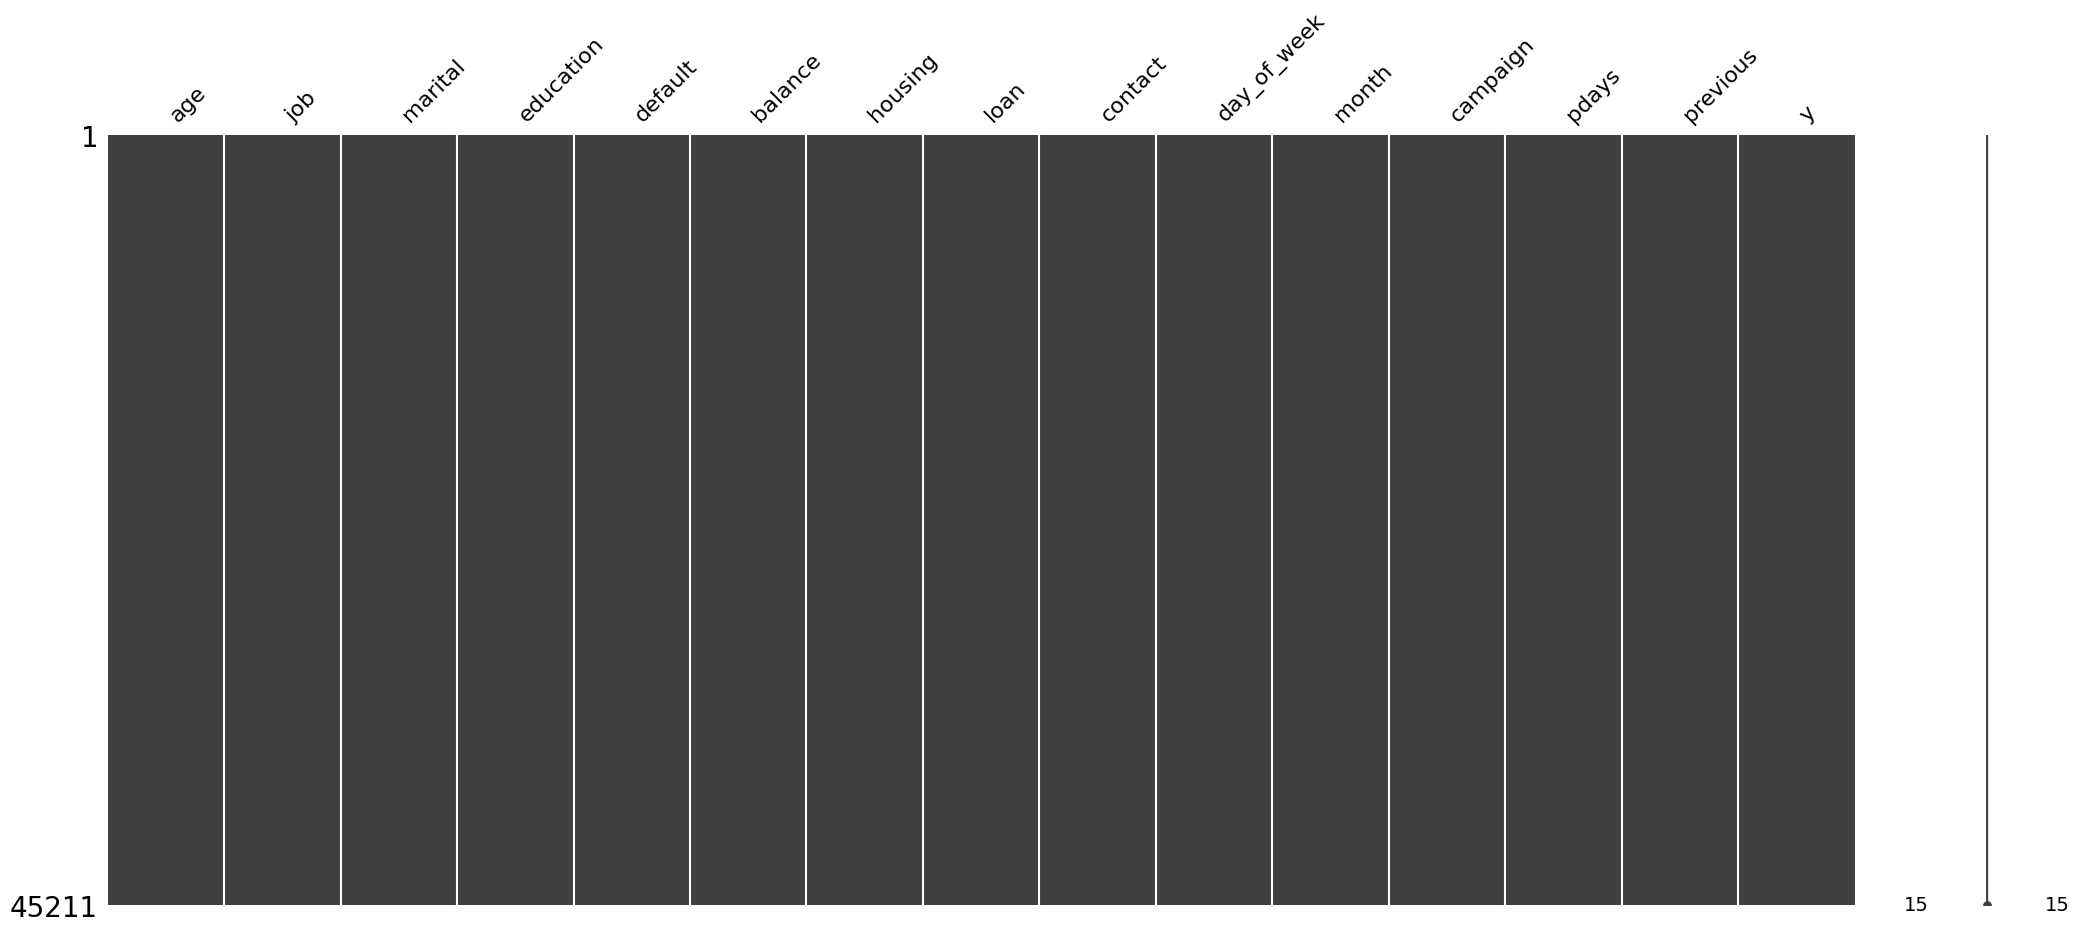

In [ ]:
msno.matrix(df);

In [ ]:
df.isna().sum().sum()

np.int64(0)

## Understanding distributions of individual features

In [ ]:
# Basic imports for functions
import matplotlib.pyplot as plt
import seaborn as sns

# UNIVARIATE PLOTTING FUNCTIONS FOR EDA
def explore_categorical(df, x, fillna = False, placeholder = 'MISSING', figsize = (6,4), order = None):

  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.tick_params(axis='x', rotation=45)
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")

  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100

  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


def explore_numeric(df, x, figsize=(6,5) ):

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

In [ ]:
cat_cols = df.select_dtypes('object').columns
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'y'],
      dtype='object')

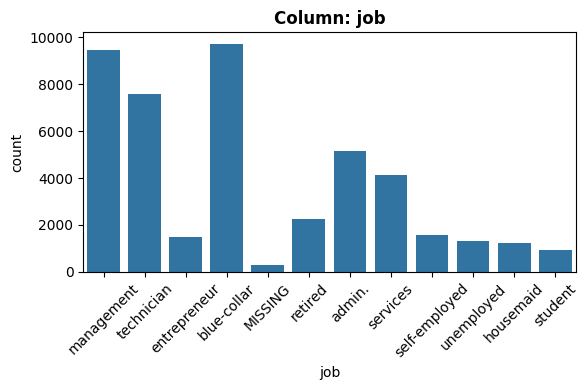

- NaN's Found: 0 (0.0%)
- Unique Values: 12
- Most common value: 'blue-collar' occurs 9732 times (21.53%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'job');

The most common job category is blue-collar, followed by management, while students represent the smallest group. This likely reflects the bank’s marketing focus on working individuals with stable income, as they are more likely to invest in term deposits compared to students.

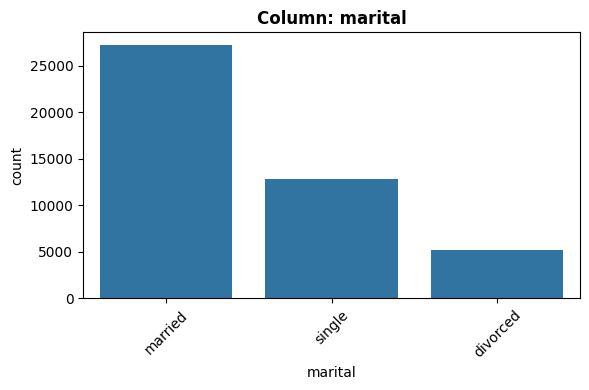

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'married' occurs 27214 times (60.19%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'marital');

Married clients represent the largest group in the dataset. This may indicate that the bank’s marketing campaigns primarily target individuals with more stable financial situations, as they are more likely to commit to long-term financial products such as term deposits.

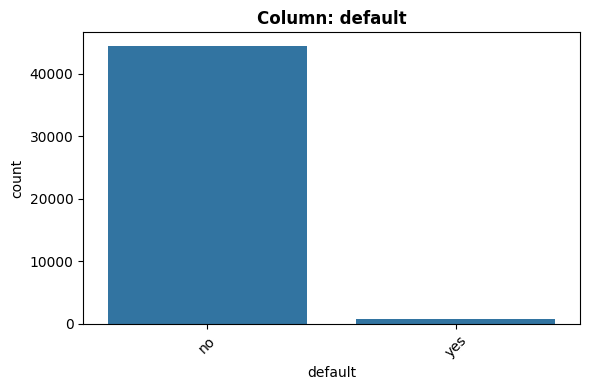

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'no' occurs 44396 times (98.2%)

- [!] Warning: 'default' is a constant or quasi-constant feature and should be dropped.


In [ ]:
explore_categorical(df, 'default');

The `default` feature is highly imbalanced, with 98.2% of values being “no”. This makes it a quasi-constant feature with very low variance, limiting its usefulness for predictive modeling. Therefore, it can be safely removed without significantly impacting model performance.

In [ ]:
df = df.drop(columns=['default'])
df.head()

,age,job,marital,education,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,y
0,58,management,married,tertiary,2143,yes,no,MISSING,5,may,1,-1,0,no
1,44,technician,single,secondary,29,yes,no,MISSING,5,may,1,-1,0,no
2,33,entrepreneur,married,secondary,2,yes,yes,MISSING,5,may,1,-1,0,no
3,47,blue-collar,married,MISSING,1506,yes,no,MISSING,5,may,1,-1,0,no
4,33,MISSING,single,MISSING,1,no,no,MISSING,5,may,1,-1,0,no


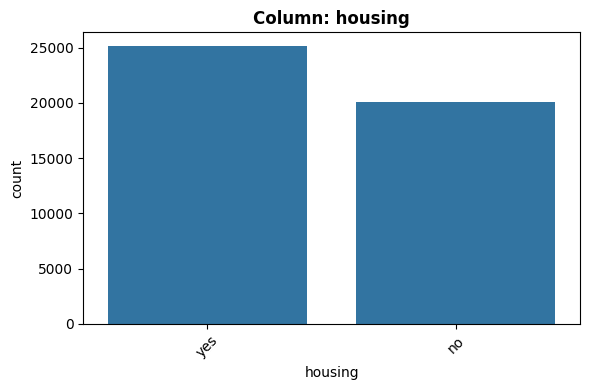

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'yes' occurs 25130 times (55.58%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'housing');

The majority of clients (55.58%) have a housing loan, indicating that a large portion of the dataset consists of financially committed individuals. This feature may influence subscription behavior, as existing financial obligations could affect a client’s ability or willingness to invest in a term deposit.

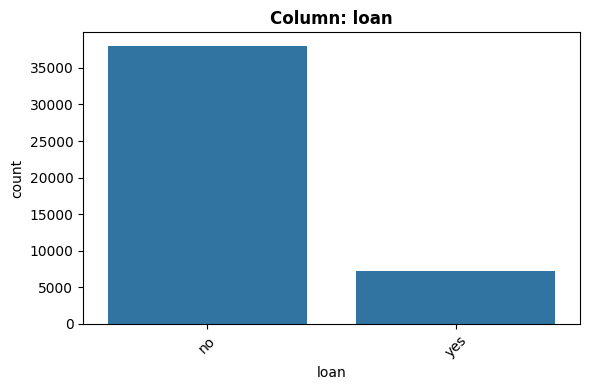

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'no' occurs 37967 times (83.98%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'loan');

The majority of clients (83.98%) do not have a personal loan, indicating that most individuals in the dataset are not heavily burdened by personal debt. This could influence subscription behavior, as clients without existing loans may have more financial flexibility to invest in term deposits.

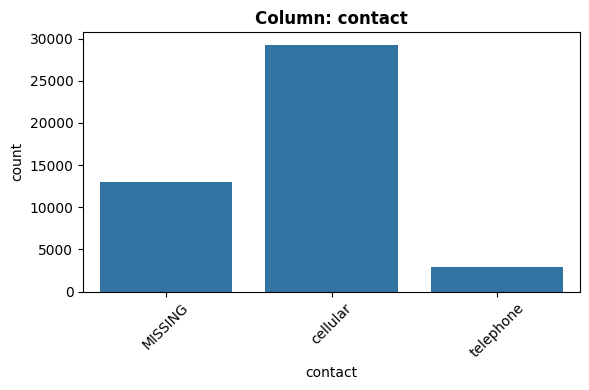

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'cellular' occurs 29285 times (64.77%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'contact');

Cellular is the most commonly used contact method, while telephone is used less frequently. The dataset also contains a significant number of missing values in this feature, which should be handled before modeling, either through imputation or by introducing an “unknown” category. Additionally, the contact method may influence client response, as different communication channels can affect engagement and conversion rates.

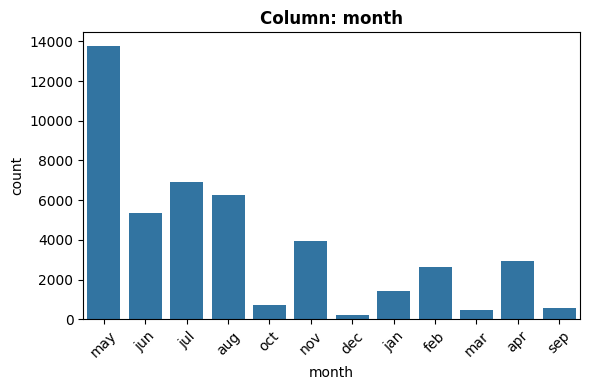

- NaN's Found: 0 (0.0%)
- Unique Values: 12
- Most common value: 'may' occurs 13766 times (30.45%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'month');

May is the most frequent month of contact, while December has the lowest number of interactions. This likely reflects the bank’s campaign scheduling, where marketing efforts are concentrated during specific periods. Seasonal patterns such as holidays (e.g., December) may reduce campaign activity and client responsiveness.

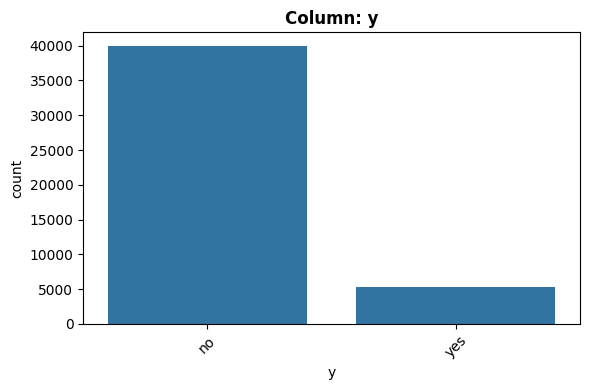

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'no' occurs 39922 times (88.3%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(df, 'y');

The target variable is highly imbalanced, with 88.3% of clients not subscribing. This imbalance may bias models toward the majority class, making evaluation metrics such as accuracy unreliable. Therefore, alternative metrics like precision, recall, and F1-score should be considered when evaluating model performance.

In [ ]:
num_cols = df.select_dtypes('number').columns
num_cols

Index(['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous'], dtype='object')

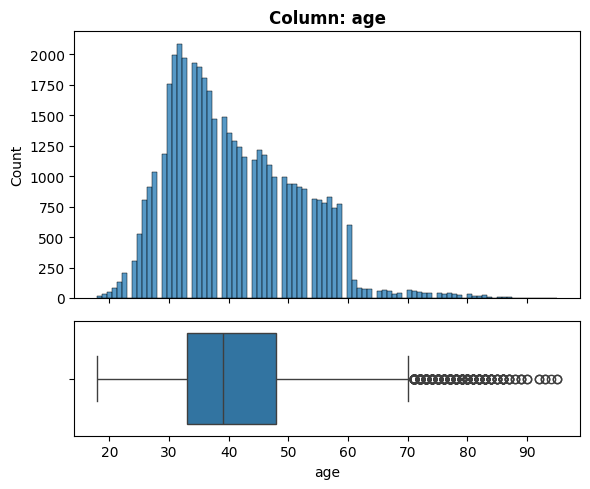

- NaN's Found: 0 (0.0%)
- Unique Values: 77
- Most common value: '32' occurs 2085 times (4.61%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'age');

The age variable shows a wide range from approximately 20 to 95 years. The boxplot indicates that the middle 50% of clients fall between 33 and 54 years (interquartile range), suggesting that most clients are middle-aged. The distribution is right-skewed, with a longer tail toward older ages, indicating that fewer clients are in higher age groups.

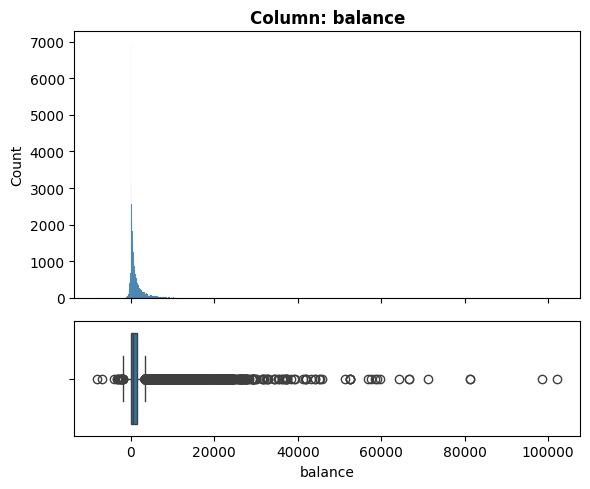

- NaN's Found: 0 (0.0%)
- Unique Values: 7168
- Most common value: '0' occurs 3514 times (7.77%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'balance');

The balance feature is highly skewed, with a large concentration of values around zero and relatively small amounts. The boxplot shows a compressed interquartile range near zero, while a long right tail in the histogram indicates the presence of a small number of clients with very high account balances. This suggests significant variability in financial status among clients, with most having low or neutral balances and a few having very high savings.

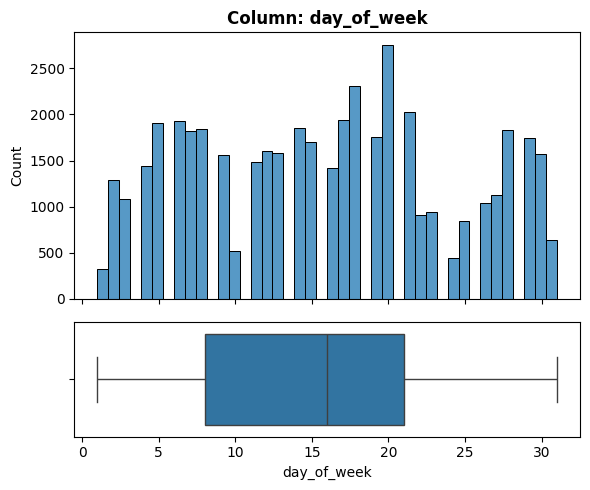

- NaN's Found: 0 (0.0%)
- Unique Values: 31
- Most common value: '20' occurs 2752 times (6.09%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'day_of_week');

The day_of_week feature shows a relatively uniform distribution, with no single value dominating the dataset. Values are spread across the available range, indicating that client contact is not concentrated on specific days. Since this feature is discrete, the boxplot is not highly informative for detecting statistical outliers, but it confirms the absence of extreme or unusual values.

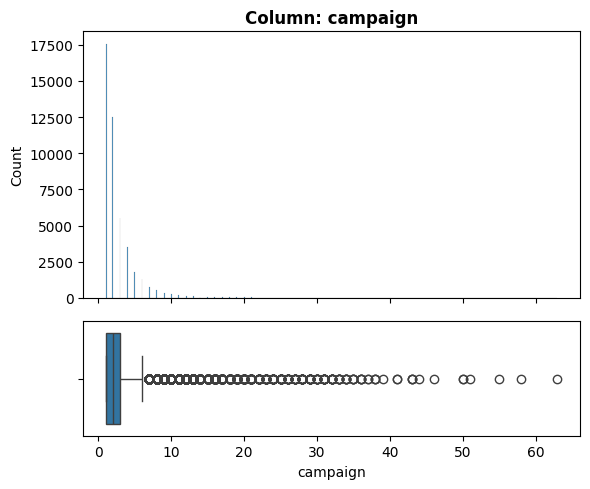

- NaN's Found: 0 (0.0%)
- Unique Values: 48
- Most common value: '1' occurs 17544 times (38.8%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'campaign');

The campaign feature represents the number of contacts made during the current marketing campaign. Most clients were contacted only once (38.8%), indicating that a single contact is often sufficient or that repeated contact is not common. However, the distribution is highly right-skewed, with a long tail of clients contacted multiple times, reflecting targeted or repeated marketing efforts. These higher values appear as extreme observations in the boxplot but represent valid campaign behavior rather than true anomalies.

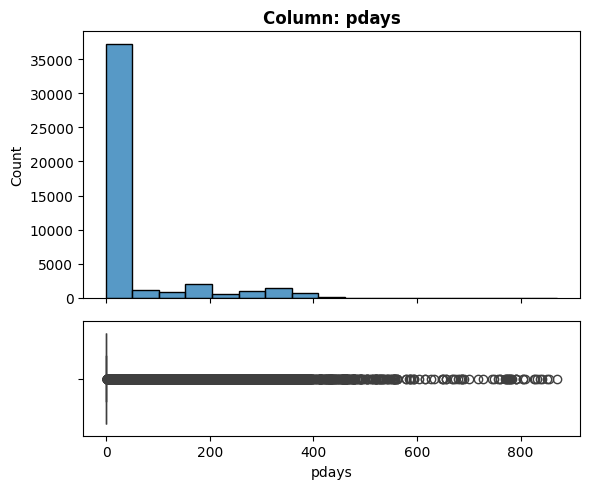

- NaN's Found: 0 (0.0%)
- Unique Values: 559
- Most common value: '-1' occurs 36954 times (81.74%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'pdays');

The pdays feature shows extreme imbalance, with 81.74% of values equal to -1, indicating that most clients were never previously contacted in past campaigns. The remaining values represent the number of days since the last contact, creating a highly skewed distribution. The boxplot appears compressed near -1 due to this dominance, while higher values form a long tail, reflecting rare cases of previous campaign interaction rather than true statistical outliers.

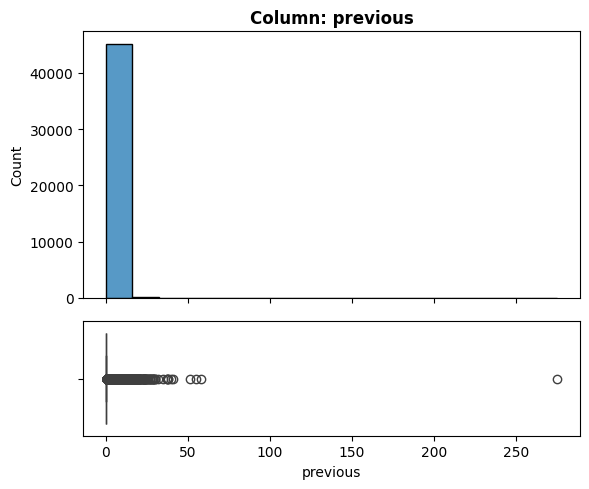

- NaN's Found: 0 (0.0%)
- Unique Values: 41
- Most common value: '0' occurs 36954 times (81.74%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(df, 'previous');

The previous feature represents the number of contacts performed before the current campaign. The majority of clients (about 81.74%) have a value of 0, indicating no prior contact history. This creates a highly right-skewed distribution, where most values are concentrated at zero and a small number of clients have multiple previous contacts. Some extreme values (e.g., around 60 and even 280) represent clients with extensive past interactions, reflecting long-term engagement rather than statistical outliers.

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan',
       'contact', 'day_of_week', 'month', 'campaign', 'pdays', 'previous',
       'y'],
      dtype='object')

## Explore relationships between features


In [ ]:
def plot_categorical_vs_target(df, x, y, figsize=(6,4), fillna = True, placeholder = 'MISSING', order = None, target_type='reg'):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()

  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])

  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

  # REGRESSION-TARGET PLOT
  if target_type=='reg': #Added if statement here
    # Barplot
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6, linewidth=1, edgecolor='black', errorbar=None)

    # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax, order=order, hue_order=order, legend=False, edgecolor='white', linewidth=0.5, size=3,zorder=0)


  # CLASSIFICATION-TARGET PLOT # This is the new code for the classification task
  elif target_type=='class':
    ax = sns.histplot(data=temp_df, hue=y, x=x, stat='percent',  multiple='fill')

  # Rotate xlabels
  ax.set_xticks(ax.get_xticks()) # Added this to prevent a bug
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

def plot_numeric_vs_target(df, x, y, figsize=(6,4), target_type='reg', estimator='mean', errorbar='ci',sorted=False,ascending=False, **kwargs): # kwargs for sns.regplot

  nulls = df[[x,y]].isna().sum()
  if nulls.sum()>0:
    print(f"- Excluding {nulls.sum()} NaN's")
    # print(nulls)
    temp_df = df.dropna(subset=[x,y,])
  else:
    temp_df = df

  # Create the figure
  fig, ax = plt.subplots(figsize=figsize)

  # REGRESSION-TARGET PLOT
  if 'reg' in target_type:
    # Calculate the correlation
    corr = df[[x,y]].corr().round(2)
    r = corr.loc[x,y]
    # Plot the data
    scatter_kws={'ec':'white','lw':1,'alpha':0.8}
    sns.regplot(data=temp_df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
    ## Add the title with the correlation
    ax.set_title(f"{x} vs. {y} (r = {r})")

  # CLASSIFICATION-TARGET PLOT
  elif 'class' in target_type:

    # Sort the groups by median/mean
    if sorted == True:

      if estimator == 'median':
        group_vals = temp_df.groupby(y)[x].median()
      elif estimator =='mean':
        group_vals = temp_df.groupby(y)[x].mean()

      ## Sort values
      group_vals = group_vals.sort_values(ascending=ascending)
      order = group_vals.index

    else:
      # Set order to None if not calcualted
      order = None


    # Left Subplot (barplot)
    sns.barplot(data=temp_df, x=y, y=x, order=order,  estimator=estimator, errorbar=errorbar, ax=ax, **kwargs)

    # Add title
    ax.set_title(f"{x} vs. {y}")

    # rotate xaxis labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


  # Final Adjustments & return
  fig.tight_layout()
  fig.show()
  return fig, ax

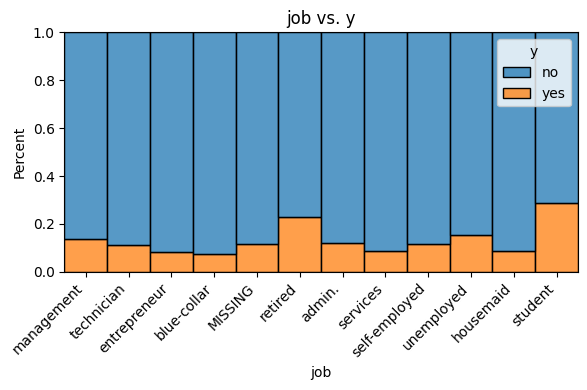

In [ ]:
plot_categorical_vs_target(df, 'job', 'y', target_type='class');

The `job` feature shows variation in subscription rates across categories. Students appear to have a higher proportion of “yes” responses compared to other job categories, while blue-collar workers show a lower proportion of subscription. This suggests that job type may influence the likelihood of subscribing to a term deposit.

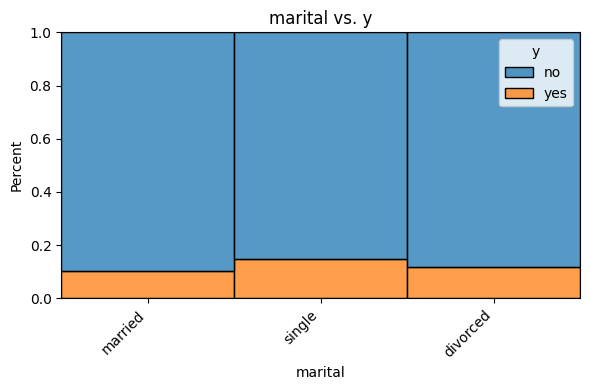

In [ ]:
plot_categorical_vs_target(df, 'marital', 'y', target_type='class');

The `marital` feature shows differences in subscription behavior. Single clients have a higher proportion of positive responses compared to married clients. This suggests that marital status may influence financial decision-making, where single individuals appear more responsive to term deposit offers than married individuals.

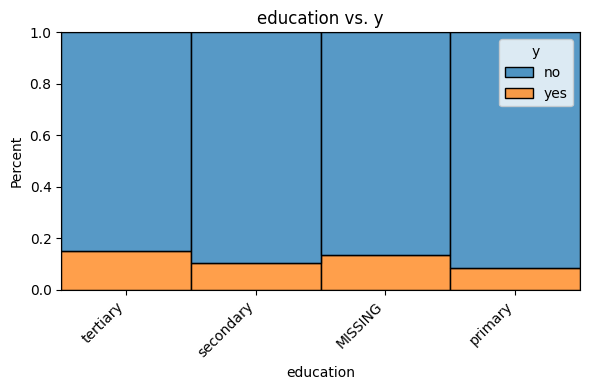

In [ ]:
plot_categorical_vs_target(df, 'education', 'y', target_type='class');

The most common education level is tertiary, indicating that a large portion of clients are highly educated. However, the feature contains a notable number of missing values, which should be handled carefully before modeling.

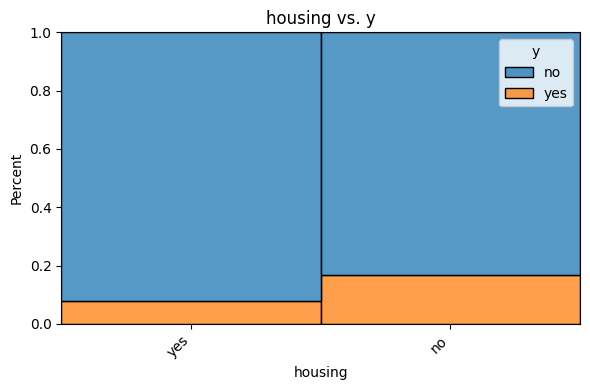

In [ ]:
plot_categorical_vs_target(df, 'housing', 'y', target_type='class');

Clients without a housing loan show a higher proportion of term deposit subscriptions compared to clients with a housing loan. This suggests that existing housing debt may reduce financial flexibility, potentially lowering the likelihood of accepting a term deposit offer.

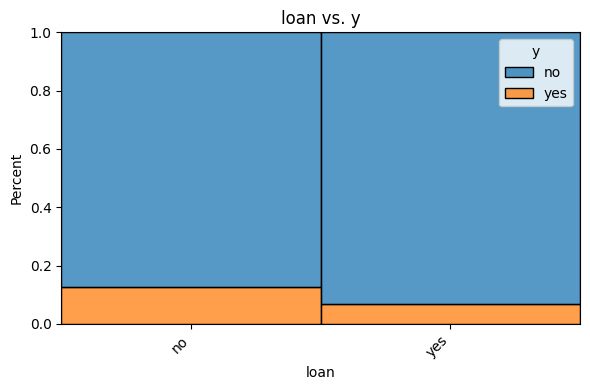

In [ ]:
plot_categorical_vs_target(df, 'loan', 'y', target_type='class');

Clients without a personal loan represent the majority of the dataset and tend to show a higher proportion of term deposit subscriptions compared to those with a loan. This suggests that existing personal debt may negatively influence a client’s likelihood of subscribing to a term deposit.

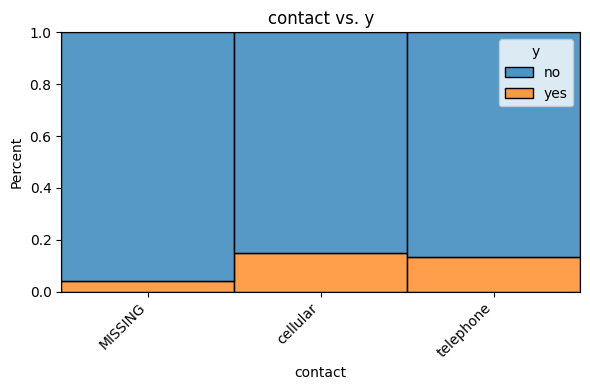

In [ ]:
plot_categorical_vs_target(df, 'contact', 'y', target_type='class');

The contact feature shows that both cellular and telephone communication methods result in similar conversion rates, with cellular being slightly higher. This suggests that the type of contact method has limited influence on subscription behavior compared to other features in the dataset.

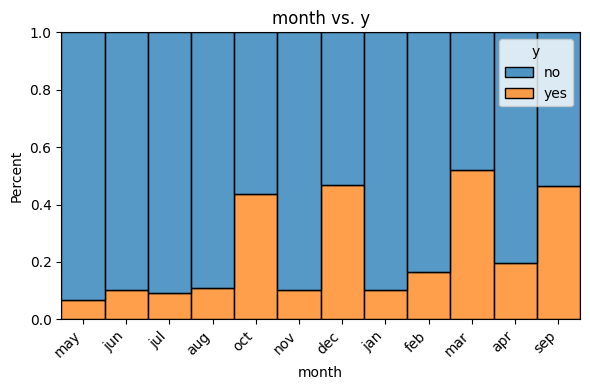

In [ ]:
plot_categorical_vs_target(df, 'month', 'y', target_type='class');

The month feature shows variation in activity, with October, December, March, and September having higher values compared to other months. This indicates that marketing activity or customer responses are not evenly distributed throughout the year, suggesting possible seasonal patterns in the campaign.

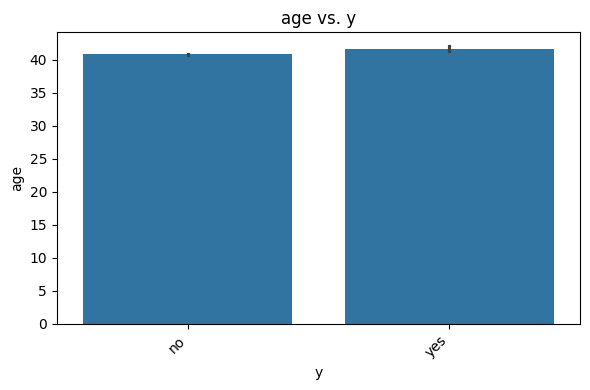

In [ ]:
plot_numeric_vs_target(df, 'age', 'y', target_type='class');

The age feature does not show a strong separation between subscribers (“yes”) and non-subscribers (“no”). Across different age values, both classes appear in similar proportions, suggesting that age alone is not a strong predictor of term deposit subscription.

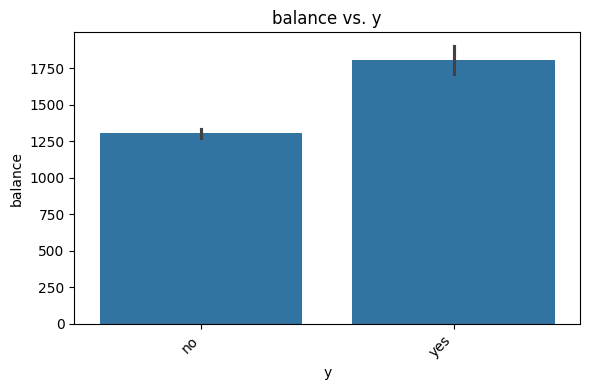

In [ ]:
plot_numeric_vs_target(df, 'balance', 'y', target_type='class');

The balance feature shows that clients who subscribed to the term deposit (“yes”) tend to have higher account balances compared to those who did not subscribe (“no”). This suggests a positive association between financial balance and subscription likelihood, where clients with more available funds may be more inclined to invest.

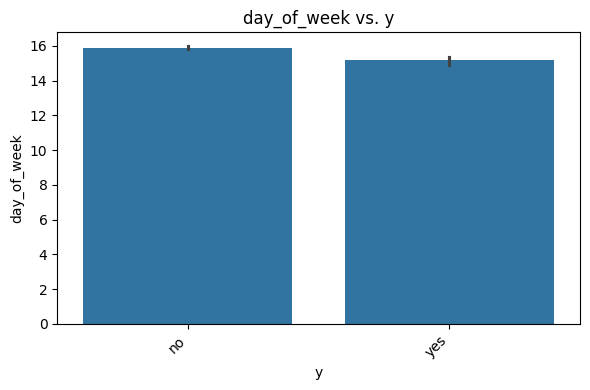

In [ ]:
plot_numeric_vs_target(df, 'day_of_week', 'y', target_type='class');

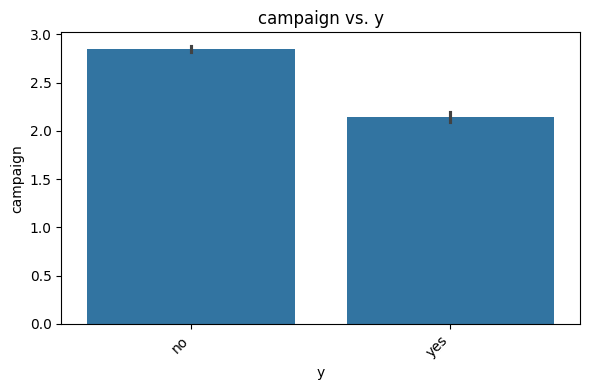

In [ ]:
plot_numeric_vs_target(df, 'campaign', 'y', target_type='class');

Clients who were contacted fewer times (especially 1–2 contacts) tend to have a higher proportion of “yes” responses, while clients contacted many times are more likely to belong to the “no” class. This suggests that repeated contact is generally associated with lower conversion probability.

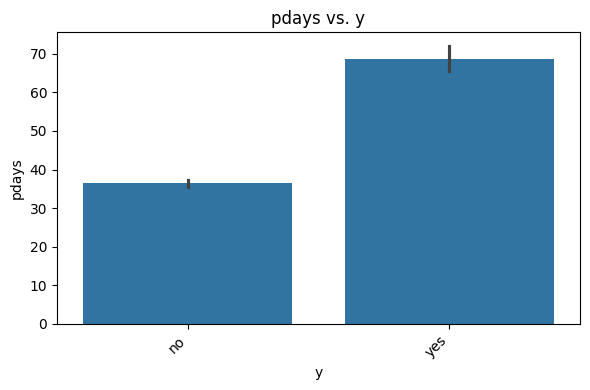

In [ ]:
plot_numeric_vs_target(df, 'pdays', 'y', target_type='class');

Clients who had been previously contacted (pdays > -1) tend to show a higher proportion of “yes” responses compared to those with no previous contact (pdays = -1). This suggests that prior engagement may increase the likelihood of subscribing to a term deposit.

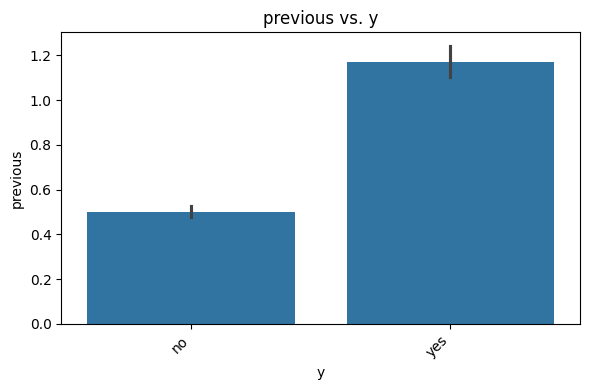

In [ ]:
plot_numeric_vs_target(df, 'previous', 'y', target_type='class');

The previous feature is highly skewed, with the majority of clients (around 81%) having no previous contact history (value = 0). Clients with at least one previous contact tend to show a higher proportion of “yes” responses compared to those with no prior interaction. This suggests that prior engagement with clients increases the likelihood of subscribing to a term deposit.

1. Target imbalance
- ~88% of clients are "no"
- Strong class imbalance
- Accuracy alone is not reliable
- Use precision, recall, F1-score and consider class weights

2. Customer profile
- Most clients are married and middle-aged (30–55)
- Main jobs: blue-collar and management
- Dataset represents working population with stable income

3. Financial features
- Higher balance is slightly associated with "yes"
- Clients without housing or personal loans tend to subscribe more
- Financial flexibility is positively related to subscription

4. Campaign behavior
- Most clients contacted 1–2 times
- More contacts in current campaign reduce success rate
- Previous contact (previous > 0) increases subscription likelihood
- Having prior contact (pdays > -1) improves conversion

5. Time features
- Some months (Dec, Oct, Mar, Sep) have higher activity
- December has the lowest activity

6. Contact method
- Cellular and telephone show similar conversion rates
- Contact method has weak predictive power

7. Demographics
- Singles show higher subscription rate than married clients
- Job type affects conversion (students higher, blue-collar lower)
- Age has weak standalone predictive power

8. Data preparation notes
- Removed ID-like and leakage features (e.g., duration)
- Missing values exist in several categorical features

Key conclusion
Subscription behavior is mainly driven by customer history (pdays, previous) and campaign intensity, while demographic features play a secondary role.

## Logistic Regression Model


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [ ]:
X

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [ ]:
X = X.drop(columns=['Unnamed: 0', 'default', 'duration'])
X

,age,job,marital,education,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,2143,yes,no,NaN,5,may,1,-1,0,NaN
1,44,technician,single,secondary,29,yes,no,NaN,5,may,1,-1,0,NaN
2,33,entrepreneur,married,secondary,2,yes,yes,NaN,5,may,1,-1,0,NaN
3,47,blue-collar,married,NaN,1506,yes,no,NaN,5,may,1,-1,0,NaN
4,33,NaN,single,NaN,1,no,no,NaN,5,may,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,825,no,no,cellular,17,nov,3,-1,0,NaN
45207,71,retired,divorced,primary,1729,no,no,cellular,17,nov,2,-1,0,NaN
45208,72,retired,married,secondary,5715,no,no,cellular,17,nov,5,184,3,success
45209,57,blue-collar,married,secondary,668,no,no,telephone,17,nov,4,-1,0,NaN


In [ ]:
y

,Unnamed: 0,y
0,0,no
1,1,no
2,2,no
3,3,no
4,4,no
...,...,...
45206,45206,yes
45207,45207,yes
45208,45208,yes
45209,45209,no


In [ ]:
y = y.drop(columns=['Unnamed: 0'])
y

,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


### Split data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
y,
no,0.883921
yes,0.116079


This dataset is imbalanced

### Preprocessing

In [ ]:
# target
target_col = "y"

# numeric columns (from X_train)
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# categorical columns (excluding target)
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

# ordinal columns (manually defined, but must exist in X_train)
ord_cols = ["education"] if "education" in X_train.columns else []

In [ ]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

num_pipe = make_pipeline(imputer, scaler)

num_tuple = ('num', num_pipe, num_cols)
num_tuple

('num',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous'])

In [ ]:
impute_cat = SimpleImputer(strategy='most_frequent')
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

cat_pipe = make_pipeline(impute_cat, ohe)

cat_tuple = ('cat', cat_pipe, cat_cols)
cat_tuple

('cat',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 ['job',
  'marital',
  'education',
  'housing',
  'loan',
  'contact',
  'month',
  'poutcome'])

In [ ]:
impute_ord = SimpleImputer(strategy='constant', fill_value='MISSING')

edu_order = ['MISSING', 'primary', 'secondary', 'tertiary']

ord_encoder = OrdinalEncoder(categories=[edu_order])  # FIXED

ord_pipe = make_pipeline(
    impute_ord,
    ord_encoder
)

ord_tuple = ('ord', ord_pipe, ord_cols)
ord_tuple

('ord',
 Pipeline(steps=[('simpleimputer',
                  SimpleImputer(fill_value='MISSING', strategy='constant')),
                 ('ordinalencoder',
                  OrdinalEncoder(categories=[['MISSING', 'primary', 'secondary',
                                              'tertiary']]))]),
 ['education'])

In [ ]:
preprocessor = ColumnTransformer([num_tuple, cat_tuple, ord_tuple], verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['age', 'balance', 'day_of_week', 'campaign',
                                  'pdays', 'previous']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['job', 'marital', 'education', 'housing',
                                  'loan', 'contact', 'month', 'poutcome']),
                                ('ord',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='MISSING',
                                                                strategy='constant')),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(categories=[['MISSING',
                                                                              'primary',
                                                                              'secondary',
                                                                              'tertiary']]))]),
                                 ['education'])],
                  verbose_feature_names_out=False)

### Model pipeline

In [ ]:
lr = LogisticRegression()
lr_pipe = make_pipeline(preprocessor, lr)
lr_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEn...
                                                  ['job', 'marital',
                                                   'education', 'housing',
                                                   'loan', 'contact', 'month',
                                                   'poutcome']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['MISSING',
                                                                                               'primary',
                                                                                               'secondary',
                                                                                               'tertiary']]))]),
                                                  ['education'])],
                                   verbose_feature_names_out=False)),
                ('logisticregression', LogisticRegression())])

In [ ]:
lr_pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEn...
                                                  ['job', 'marital',
                                                   'education', 'housing',
                                                   'loan', 'contact', 'month',
                                                   'poutcome']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['MISSING',
                                                                                               'primary',
                                                                                               'secondary',
                                                                                               'tertiary']]))]),
                                                  ['education'])],
                                   verbose_feature_names_out=False)),
                ('logisticregression', LogisticRegression())])

In [ ]:
def classification_metrics(y_true, y_pred, label='', output_dict=False, figsize=(8,4), normalize='true', cmap='Blues', colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)

  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)

  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)

  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None, cmap='gist_gray', colorbar=colorbar, ax = axes[0],);
  axes[0].set_title("Raw Counts")

  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize, cmap=cmap, colorbar=colorbar, ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()

  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.90      0.99      0.94     29972
         yes       0.65      0.17      0.27      3936

    accuracy                           0.89     33908
   macro avg       0.78      0.58      0.61     33908
weighted avg       0.87      0.89      0.86     33908



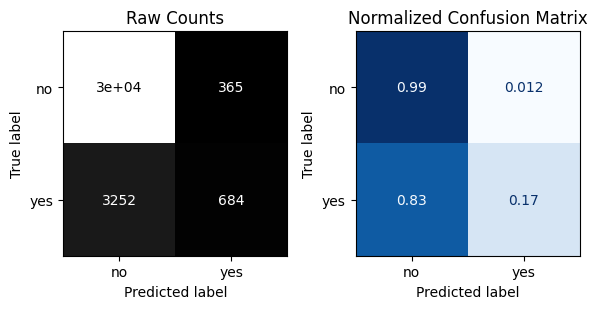


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.90      0.99      0.94      9950
         yes       0.66      0.18      0.28      1353

    accuracy                           0.89     11303
   macro avg       0.78      0.58      0.61     11303
weighted avg       0.87      0.89      0.86     11303



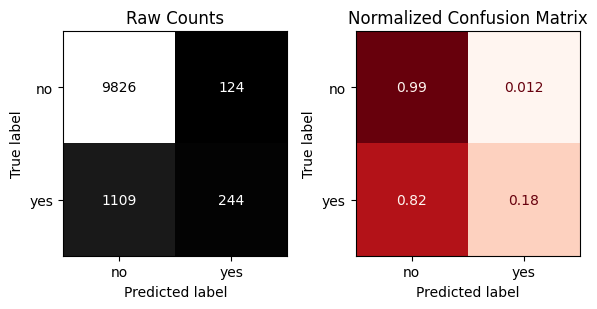

In [ ]:
evaluate_classification(lr_pipe, X_train, y_train, X_test, y_test)

Model Evaluation Insight (Logistic Regression)

The model achieves good overall accuracy (~89%) on both training and test sets, indicating stable generalization and no clear overfitting.

However, the performance on the minority class ("yes") is very weak:
- Precision for "yes" is around 0.65–0.66
- Recall for "yes" is very low (~0.17–0.18)
- This indicates a high number of false negatives, where the model fails to identify most clients who will subscribe.

In contrast, the model performs very well on the majority class ("no"), with very high recall (~0.99). This confirms that the model is biased toward the dominant class due to the strong class imbalance.

Overall, the model is effective at identifying non-subscribers but struggles to detect actual subscribers, which is the more important business objective. Improving recall for the "yes" class should be the main focus in the next iteration.

In [ ]:
lr_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    ['age', 'balance', 'day_of_week', 'campaign',
                                     'pdays', 'previous']),
                                   ('cat',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),


In [ ]:
param_grid = {
    "logisticregression__C": [0.01, 0.1, 1, 10, 100],
    "logisticregression__class_weight": [None, "balanced"],
    "logisticregression__penalty": ["l2", "l1"],
    "logisticregression__solver": ["liblinear", "saga"],
    "logisticregression__max_iter": [100, 200, 500]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

lr_gs = GridSearchCV(lr_pipe, param_grid, scoring='recall_macro', cv=3)
lr_gs.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'balance',
                                                                          'day_of_week',
                                                                          'campaign',
                                                                          'pdays',
                                                                          'previous']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent'...
                                                          verbose_feature_names_out=False)),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100],
                         'logisticregression__class_weight': [None, 'balanced'],
                         'logisticregression__max_iter': [100, 200, 500],
                         'logisticregression__penalty': ['l2', 'l1'],
                         'logisticregression__solver': ['liblinear', 'saga']},
             scoring='recall_macro')

In [ ]:
lr_gs.best_params_

{'logisticregression__C': 1,
 'logisticregression__class_weight': 'balanced',
 'logisticregression__max_iter': 100,
 'logisticregression__penalty': 'l1',
 'logisticregression__solver': 'saga'}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.94      0.78      0.85     29972
         yes       0.26      0.60      0.37      3936

    accuracy                           0.76     33908
   macro avg       0.60      0.69      0.61     33908
weighted avg       0.86      0.76      0.80     33908



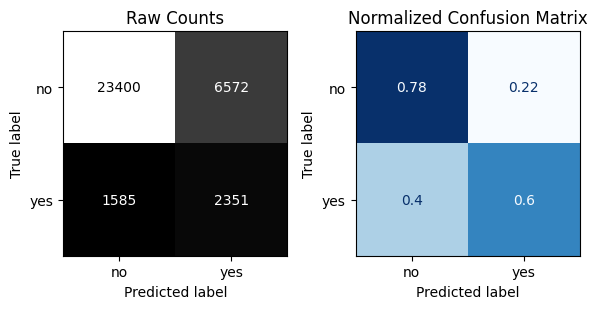


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.93      0.78      0.85      9950
         yes       0.27      0.59      0.37      1353

    accuracy                           0.76     11303
   macro avg       0.60      0.69      0.61     11303
weighted avg       0.85      0.76      0.79     11303



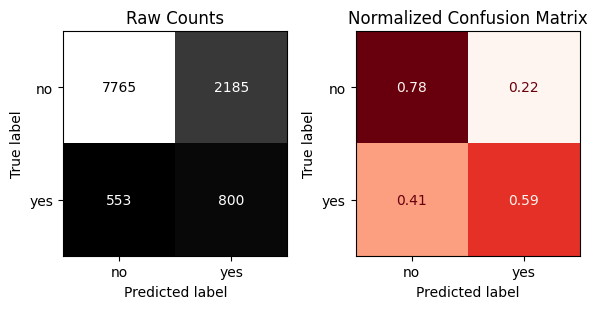

In [ ]:
evaluate_classification(lr_gs.best_estimator_,X_train, y_train, X_test, y_test)

Model Evaluation After Hyperparameter Tuning (Logistic Regression)

The tuned model shows a clear change in performance compared to the baseline model.

Overall accuracy decreased from ~0.89 to ~0.76. This drop is expected because the model is no longer biased toward the majority class and is now giving more importance to the minority class (“yes”).

For the “no” class, the model still performs well with high precision (0.93–0.94) and reasonable recall (0.78). This indicates that it is still effective at identifying non-subscribers, although it now makes more mistakes compared to the baseline model.

For the “yes” class, there is a significant improvement in recall (0.59–0.60 compared to the previous 0.17). This means the model is now able to correctly identify many more actual subscribers. However, precision remains low (0.26–0.27), meaning there are still many false positives.

The main outcome of tuning is a trade-off: the model sacrifices overall accuracy and precision in order to significantly improve its ability to detect the minority class.

This behavior is mainly driven by:
- class_weight='balanced', which forces the model to pay more attention to the minority class
- L1 regularization, which reduces feature complexity and helps focus on the most relevant signals
- the SAGA solver, which supports L1 regularization efficiently

Overall, the tuned model is more suitable for use cases where detecting potential subscribers is more important than minimizing false positives.

## Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf_pipe = make_pipeline(preprocessor, rf)
rf_pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEn...
                                                   'education', 'housing',
                                                   'loan', 'contact', 'month',
                                                   'poutcome']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['MISSING',
                                                                                               'primary',
                                                                                               'secondary',
                                                                                               'tertiary']]))]),
                                                  ['education'])],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier', RandomForestClassifier())])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

          no       1.00      1.00      1.00     29972
         yes       1.00      1.00      1.00      3936

    accuracy                           1.00     33908
   macro avg       1.00      1.00      1.00     33908
weighted avg       1.00      1.00      1.00     33908



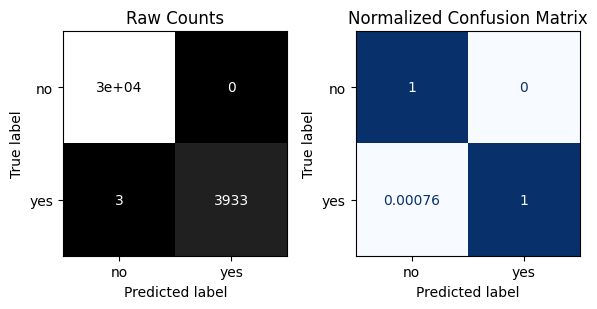


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.90      0.98      0.94      9950
         yes       0.64      0.23      0.34      1353

    accuracy                           0.89     11303
   macro avg       0.77      0.61      0.64     11303
weighted avg       0.87      0.89      0.87     11303



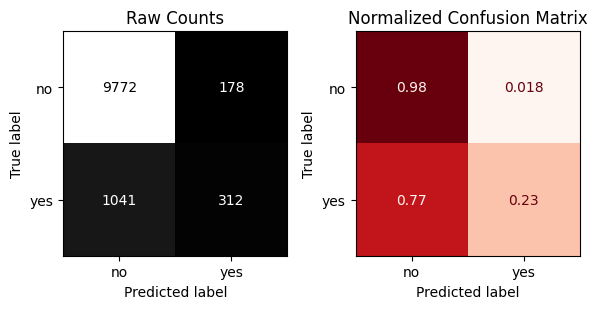

In [ ]:
evaluate_classification(rf_pipe,X_train, y_train, X_test, y_test)

Random Forest Model Evaluation (Default)

The default Random Forest model shows perfect performance on the training data, with all metrics reaching 1.00 for both classes. This indicates that the model has fully memorized the training set and is heavily overfitting.

On the test data, performance drops significantly compared to training results. The overall accuracy is around 0.89, which is similar to previous models, but the performance on the minority class ("yes") remains weak. While precision for "yes" is moderate (0.64), recall is very low (0.23), meaning the model fails to correctly identify most actual subscribers.

For the majority class ("no"), the model performs very well, with very high recall (~0.98), showing a strong bias toward predicting the dominant class.

Overall, the model does not improve minority class detection compared to Logistic Regression. It suffers from overfitting and class imbalance issues when using default parameters.

The main conclusion is that Random Forest requires hyperparameter tuning (such as limiting tree depth and handling class imbalance) before it can be fairly compared or considered a better model than Logistic Regression.

In [ ]:
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    ['age', 'balance', 'day_of_week', 'campaign',
                                     'pdays', 'previous']),
                                   ('cat',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),


In [ ]:
param_grid = {
    "randomforestclassifier__n_estimators": [100, 200],
    "randomforestclassifier__max_depth": [10, 20],
    "randomforestclassifier__min_samples_split": [2, 5],
    "randomforestclassifier__min_samples_leaf": [1, 2],
    "randomforestclassifier__class_weight": [None, "balanced"]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_gs = RandomizedSearchCV(rf_pipe, param_grid, n_iter=20, scoring='recall_macro', cv=3, n_jobs=-1, verbose=10)
rf_gs.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('standardscaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'balance',
                                                                                'day_of_week',
                                                                                'campaign',
                                                                                'pdays',
                                                                                'previous']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='most_fre...
                                              RandomForestClassifier())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'randomforestclassifier__class_weight': [None,
                                                                                 'balanced'],
                                        'randomforestclassifier__max_depth': [10,
                                                                              20],
                                        'randomforestclassifier__min_samples_leaf': [1,
                                                                                     2],
                                        'randomforestclassifier__min_samples_split': [2,
                                                                                      5],
                                        'randomforestclassifier__n_estimators': [100,
                                                                                 200]},
                   scoring='recall_macro', verbose=10)

In [ ]:
rf_gs.best_params_

{'randomforestclassifier__n_estimators': 100,
 'randomforestclassifier__min_samples_split': 5,
 'randomforestclassifier__min_samples_leaf': 2,
 'randomforestclassifier__max_depth': 10,
 'randomforestclassifier__class_weight': 'balanced'}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.94      0.88      0.91     29972
         yes       0.40      0.60      0.48      3936

    accuracy                           0.85     33908
   macro avg       0.67      0.74      0.70     33908
weighted avg       0.88      0.85      0.86     33908



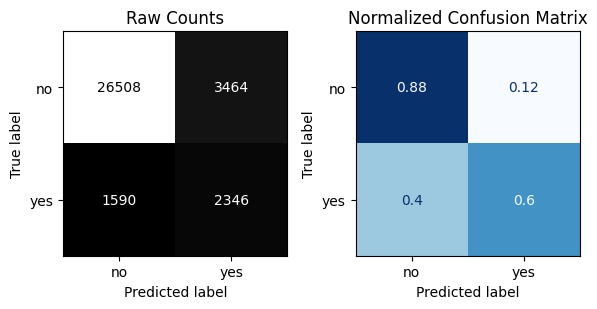


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

          no       0.93      0.88      0.90      9950
         yes       0.37      0.54      0.44      1353

    accuracy                           0.84     11303
   macro avg       0.65      0.71      0.67     11303
weighted avg       0.87      0.84      0.85     11303



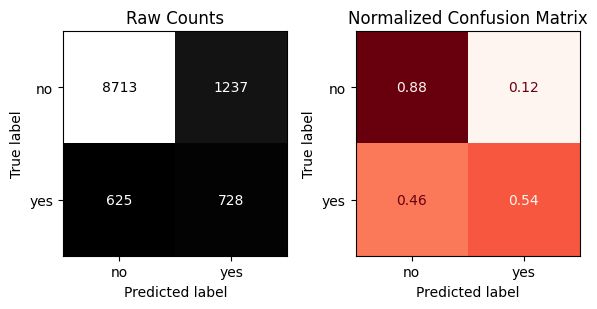

In [ ]:
evaluate_classification(rf_gs.best_estimator_,X_train, y_train, X_test, y_test)

Random Forest Model Evaluation (Tuned)

The tuned Random Forest model shows a clear improvement compared to both the default Random Forest and the initial Logistic Regression in terms of balancing class performance.

On the training data, the model achieves strong but realistic performance (accuracy 0.85), indicating that overfitting has been reduced compared to the default model. The "no" class shows high precision (0.94) and good recall (0.88), while the "yes" class shows improved recall (0.60), meaning the model is now able to capture more actual subscribers.

On the test data, the model maintains similar performance (accuracy ~0.84), which confirms good generalization. However, the "yes" class is still the main challenge, with precision around 0.37 and recall around 0.54. This indicates that while the model successfully identifies more potential subscribers, it still produces a relatively high number of false positives.

Overall, the model achieves a better balance between classes compared to previous models, but there is still a trade-off between recall and precision for the minority class.

In [ ]:
# If y_test is a DataFrame, select the column containing the target labels
y_test_numeric = y_test['y'].apply(lambda x: 0 if x == 'no' else 1)

   threshold  precision    recall        f1
0        0.5   0.370483  0.538064  0.438819
1        0.4   0.227474  0.722099  0.345963
2        0.3   0.145363  0.918699  0.251010


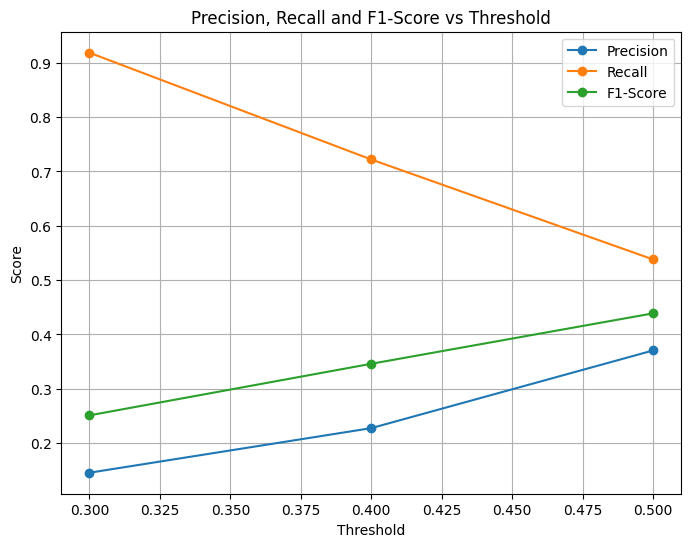

In [ ]:
# Convert y_test to numeric (0 for 'no', 1 for 'yes')
y_test_numeric = y_test['y'].map({'no': 0, 'yes': 1})

# Proceed with the rest of the code
y_proba = rf_gs.best_estimator_.predict_proba(X_test)[:, 1]
metrics = {'threshold': [], 'precision': [], 'recall': [], 'f1': []}

# Try different thresholds
for threshold in thresholds:
    # Predict class labels based on threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Calculate precision, recall, and f1-score
    report = classification_report(y_test_numeric, y_pred, output_dict=True)

    # Store the metrics
    metrics['threshold'].append(threshold)
    metrics['precision'].append(report['1']['precision'])
    metrics['recall'].append(report['1']['recall'])
    metrics['f1'].append(report['1']['f1-score'])

# Print the metrics summary
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(metrics_df['threshold'], metrics_df['precision'], label='Precision', marker='o')
plt.plot(metrics_df['threshold'], metrics_df['recall'], label='Recall', marker='o')
plt.plot(metrics_df['threshold'], metrics_df['f1'], label='F1-Score', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1-Score vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

           0       0.95      0.67      0.78      9950
           1       0.23      0.72      0.35      1353

    accuracy                           0.67     11303
   macro avg       0.59      0.69      0.56     11303
weighted avg       0.86      0.67      0.73     11303

Confusion Matrix:
[[6632 3318]
 [ 376  977]]


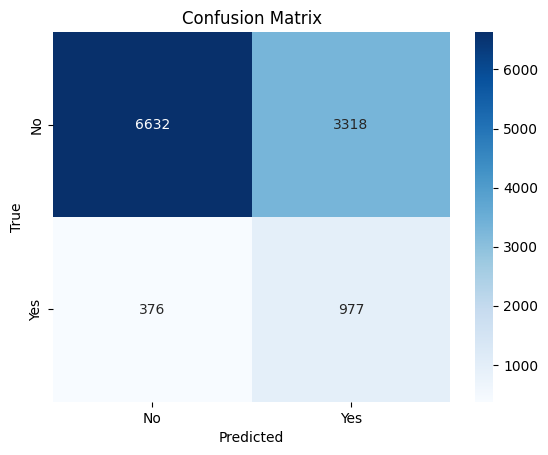

In [ ]:
# Get the probability of positive class (1) for test data
y_proba = rf_gs.best_estimator_.predict_proba(X_test)[:, 1]

# Set the threshold to 0.3 and predict based on it
y_pred = (y_proba >= 0.4).astype(int)

# Convert y_test to numeric (0 for 'no', 1 for 'yes')
y_test_numeric = y_test['y'].map({'no': 0, 'yes': 1})

# Evaluate performance using classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix

# Classification report
report = classification_report(y_test_numeric, y_pred)
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(y_test_numeric, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# If you want to plot confusion matrix:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**Model Evaluation Insights**

After experimenting with various thresholds for classification, the following conclusions can be drawn:

1. **Threshold Adjustments**:
   - We tested different thresholds (0.5, 0.4, 0.3) to optimize the model's **precision**, **recall**, and **F1-score** for the target variable **'yes'**.
   - A **threshold of 0.4** was found to provide the best balance between precision and recall.

2. **Performance Metrics**:
   - **Precision for 'no'** remains high at **0.95**, indicating that the model is very good at correctly predicting the majority class (no).
   - **Recall for 'yes'** significantly improved to **0.72**, showing that the model correctly identifies 72% of all actual positive instances (yes).
   - **Precision for 'yes'** is still low at **0.23**, meaning that the model is still over-predicting **'no'** when **'yes'** is the true class.
   - **F1-score for 'yes'** is **0.35**, suggesting a better but still suboptimal balance between precision and recall for the minority class.

3. **Confusion Matrix**:
   - The confusion matrix indicates the model's performance: 6632 **True Negatives**, 3318 **False Positives**, 376 **False Negatives**, and 977 **True Positives**.
   - The model correctly predicted a significant portion of **'no'** (majority class), while still managing to detect a good portion of **'yes'** (minority class) despite the class imbalance.

4. **Accuracy**:
   - **Accuracy** reached **0.67**, a reasonable result considering the imbalance in the dataset, where **'no'** samples dominate.